# Phase 9 (Part B) — Horizon Sensitivity Investigation
### Energy Demand Forecasting Project

**Questions this phase answers:** Phases 5-8 and Part A only ever asked
"which model wins at 24h-ahead?". This phase asks two new ones: *how does
each model's error behave as the forecasting horizon changes -- 1h vs. 24h
vs. 7d ahead?* and *does the model that wins at 24h still win at the other
two horizons, or does the best choice change with horizon?*

**Scope decisions, flagged upfront rather than buried in code:**

- **1h horizon:** no new model fits. Every model in the 24h benchmark
  (Phases 5-8) already produces a genuine 1-step-ahead prediction as part
  of its existing backtest -- LightGBM has a model trained *specifically*
  for h=1, SARIMA/Prophet/LSTM's h=1 output is a real 1-hour-ahead forecast
  from their existing rolling/continuous backtests. So the 1h comparison
  below just re-slices the already-saved Phase 5-8 results at
  `horizon_step == 1` -- zero refitting. The one trade-off: those origins
  are spaced a day apart (288 of them), not genuinely one-per-hour, which
  keeps this cheap but means the 1h sample is a subset of hours-of-day
  rather than an hourly-resolution sweep. A true hourly-origin 1h backtest
  is future work, not needed to answer this phase's two questions.
- **7d (168h) horizon:** this genuinely requires new backtests -- nothing
  saved so far forecasts past h=24. SARIMA and Prophet reuse the exact
  hyperparameters/order Phases 6-7 already found (no re-search); LightGBM
  reuses Phase 7's tuned params, fitting 168 direct per-horizon models
  instead of 24. Origins are spaced 7 days apart (`origin_freq="7d"`),
  matching the horizon exactly for non-overlapping windows -- the same
  design choice the 24h benchmark made with `origin_freq="24h"`.
- **LSTM at 7d is skipped**, exactly as the roadmap flags as optional --
  a 168-step direct decode head is a different architecture, not a
  parameter change, and isn't needed to answer either question above given
  LightGBM/SARIMA/Prophet already cover the required comparison.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import (
    get_forecast_origins, run_backtest, compute_metrics,
    naive_forecast, daily_seasonal_naive, weekly_seasonal_naive,
    extended_daily_seasonal_naive,
)
from src.evaluation.continuous import to_backtest_format
from src.evaluation.results_store import load_results, save_results
from src.models.sarima import fit_model as fit_sarima, rolling_backtest
from src.models.prophet_model import fit_model as fit_prophet, forecast_continuous
from src.models.lightgbm_direct import fit_direct_models, direct_multi_horizon_backtest

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data and reuse the shared train/test split

In [3]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
features_raw = con.execute("SELECT * FROM hourly_features ORDER BY datetime").df()
con.close()

hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"].asfreq("h")

features_raw["datetime"] = pd.to_datetime(features_raw["datetime"])
features_df = features_raw.set_index("datetime").asfreq("h")

test_start = get_train_test_split(series, test_frac=0.2)
train = series.loc[:test_start].asfreq("h")

print(f"Test starts: {test_start} | Train hours: {len(train):,}")

Test starts: 2010-02-11 00:00:00 | Train hours: 27,656


## A leak-free extension of `daily_seasonal_naive`, valid at any horizon

This notebook's 7d backtest excludes `daily_seasonal_naive` entirely, since
its fixed 24h lag leaks future data once horizon > 24h (see
`src/evaluation/baselines.py`'s `_lagged_forecast` guard). Rather than just
leave that gap, `extended_daily_seasonal_naive` closes it cheaply: instead
of looking up a different day-ago value per step, it looks up exactly one
24h block ending at `origin` and tiles it forward across however long the
horizon is. Every value it reads is at or before `origin`, so it's leak-
free at any horizon -- and it's mathematically identical to
`daily_seasonal_naive` whenever horizon<=24 (verified by test, not just
asserted), so this is a genuine like-for-like extension of the same
"recency" baseline, not a different method wearing its name. Computed fresh
at the 24h-origin grid here (giving both the 1h and 24h comparison points);
the 7d point comes from including it in the 168h baseline backtest below.

In [4]:
canonical_origins_24h = get_forecast_origins(series, test_start, horizon=24)
extended_24h = run_backtest(
    series, {"extended_daily_seasonal_naive": extended_daily_seasonal_naive},
    canonical_origins_24h, horizon=24,
)
print(f"extended_daily_seasonal_naive computed at {len(canonical_origins_24h)} origins (horizon=24)")

extended_daily_seasonal_naive computed at 288 origins (horizon=24)


## 1h horizon -- re-slicing the existing 24h-benchmark results

`naive` (flat persistence) is included here specifically because it's the
theoretically hardest baseline to beat at a 1-hour horizon -- consecutive
hourly readings are highly correlated, unlike at 24h where `daily_seasonal_
naive` was the stronger reference point.

In [5]:
baselines = load_results("baselines")
sarima_arima = load_results("sarima_arima")
prophet_24h = load_results("prophet")
lightgbm_24h = load_results("lightgbm_direct")
lstm_24h = load_results("lstm")

results_24h = pd.concat(
    [baselines, sarima_arima, prophet_24h, lightgbm_24h, lstm_24h, extended_24h], ignore_index=True,
)
results_1h = results_24h[results_24h["horizon_step"] == 1].copy()

metrics_1h = {
    method: compute_metrics(results_1h[results_1h["method"] == method])
    for method in results_1h["method"].unique()
}
pd.DataFrame(metrics_1h).T.sort_values("MAE")

,MAE,RMSE,MAPE,sMAPE,n
lstm,0.207218,0.323588,34.989511,35.214380,271.0
lightgbm,0.210530,0.337986,34.801634,33.840560,258.0
naive,0.231489,0.392728,44.007225,32.770741,279.0
sarima,0.273990,0.393658,57.224972,43.573383,279.0
arima,0.281348,0.408426,59.519001,42.024032,279.0
daily_seasonal_naive,0.292641,0.487116,53.065810,41.605522,276.0
extended_daily_seasonal_naive,0.292641,0.487116,53.065810,41.605522,276.0
prophet,0.317767,0.465562,57.465268,63.983368,279.0
weekly_seasonal_naive,0.346854,0.547545,69.394948,49.058648,270.0


## 7d (168h) horizon -- new backtests

Origins spaced 7 days apart, matching the 168h horizon exactly (non-
overlapping windows).

In [6]:
HORIZON_7D = 168
origins_7d = get_forecast_origins(series, test_start, horizon=HORIZON_7D, origin_freq="7d")
print(f"7d-horizon origins: {len(origins_7d)} ({origins_7d.min().date()} to {origins_7d.max().date()})")

7d-horizon origins: 41 (2010-02-11 to 2010-11-18)


### Baselines at 168h

`weekly_seasonal_naive` (lag 168h) is the natural reference here -- lag
exactly matches horizon, i.e. "next week looks like this week". The
original `daily_seasonal_naive` is deliberately **excluded** at this
horizon: its fixed 24h lag only stays leak-free while
`horizon <= lag_hours` (see `src/evaluation/baselines.py`'s
`_lagged_forecast` guard) -- at a 168h horizon, its forecast for steps past
h=24 would look up a value up to 144h *after* the origin, i.e. future data.
`extended_daily_seasonal_naive` (see above) stands in for it here instead --
same "recency" idea, but leak-free at this horizon.

In [7]:
baseline_methods = {
    "naive": naive_forecast,
    "weekly_seasonal_naive": weekly_seasonal_naive,
    "extended_daily_seasonal_naive": extended_daily_seasonal_naive,
}
baselines_7d = run_backtest(series, baseline_methods, origins_7d, horizon=HORIZON_7D)
save_results(baselines_7d, "baselines_7d")

Saved 20,664 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/baselines_7d.parquet


### SARIMA at 168h

Reuses Phase 6's auto_arima-selected order (3,1,0)(2,0,0)[24] and 4,380-hour
fit window -- no re-search, just refitting the same specification and
forecasting further ahead.

In [8]:
fit_window = train.iloc[-4380:].asfreq("h")
sarima_fit_7d = fit_sarima(fit_window, order=(3, 1, 0), seasonal_order=(2, 0, 0, 24))

sarima_7d = rolling_backtest(
    series, sarima_fit_7d, origins_7d, horizon=HORIZON_7D,
    method_name="sarima", window_hours=len(fit_window),
)
save_results(sarima_7d, "sarima_7d")

Saved 6,888 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/sarima_7d.parquet


### Prophet at 168h

Prophet already forecasts one continuous series across the whole test
period regardless of horizon -- refitting and re-slicing at a longer
horizon needs no other change.

In [9]:
prophet_model_7d = fit_prophet(train)
periods_needed = int((series.index.max() - train.index.max()) / pd.Timedelta(hours=1))
prophet_forecast_7d = forecast_continuous(prophet_model_7d, periods=periods_needed)

prophet_7d = to_backtest_format(prophet_forecast_7d, series, origins_7d, HORIZON_7D, "prophet")
save_results(prophet_7d, "prophet_7d")

12:28:35 - cmdstanpy - INFO - Chain [1] start processing


12:28:37 - cmdstanpy - INFO - Chain [1] done processing


Saved 6,888 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/prophet_7d.parquet


### LightGBM at 168h

168 direct per-horizon models instead of 24, reusing Phase 7's tuned
hyperparameters (tuned once on h=24, same trade-off Phase 7 already made
and flagged -- not re-tuned per horizon here either).

In [10]:
best_params = {
    "n_estimators": 371, "learning_rate": 0.02641663667830087, "num_leaves": 61,
    "max_depth": 8, "min_child_samples": 24, "subsample": 0.7290233432213763,
    "colsample_bytree": 0.995734826483326, "objective": "regression", "verbosity": -1,
}

lgb_models_7d = fit_direct_models(
    features_df, train_end=test_start, horizons=range(1, HORIZON_7D + 1), lgb_params=best_params,
)
lightgbm_7d = direct_multi_horizon_backtest(
    features_df, lgb_models_7d, origins_7d, horizon_max=HORIZON_7D, method_name="lightgbm",
)
save_results(lightgbm_7d, "lightgbm_7d")

Saved 6,216 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/lightgbm_7d.parquet


### 7d metrics

In [11]:
results_7d = pd.concat([baselines_7d, sarima_7d, prophet_7d, lightgbm_7d], ignore_index=True)

metrics_7d = {
    method: compute_metrics(results_7d[results_7d["method"] == method])
    for method in results_7d["method"].unique()
}
pd.DataFrame(metrics_7d).T.sort_values("MAE")

,MAE,RMSE,MAPE,sMAPE,n
lightgbm,0.444357,0.603866,66.355552,46.230880,6078.0
prophet,0.484548,0.636557,72.594083,54.650323,6658.0
extended_daily_seasonal_naive,0.551528,0.793323,72.224245,52.239031,6582.0
weekly_seasonal_naive,0.563600,0.814513,76.759148,53.715477,6428.0
naive,0.794490,1.109266,91.678381,74.116885,6582.0
sarima,0.827229,1.189896,119.051047,76.513522,6658.0


## Horizon sensitivity -- 1h vs. 24h vs. 7d, per model

For a clean, comparable read on "how hard is exactly-this-far-ahead
forecasting", each horizon's number is the error at *exactly* that horizon
step (h=1, h=24, h=168) from its respective backtest -- not a blended
average across 1-24 -- so the three points per model are genuinely
comparable single-step accuracies at three different distances.

In [12]:
h24_exact = results_24h[results_24h["horizon_step"] == 24]
h1_exact = results_1h  # already horizon_step == 1
h168_exact = results_7d[results_7d["horizon_step"] == HORIZON_7D]

METHODS_ALL_HORIZONS = [
    "naive", "daily_seasonal_naive", "extended_daily_seasonal_naive",
    "weekly_seasonal_naive", "sarima", "prophet", "lightgbm",
]
METHODS_WITH_LSTM = METHODS_ALL_HORIZONS + ["lstm"]

rows = []
for method in METHODS_WITH_LSTM:
    row = {"method": method}
    for label, df, target_h in [("1h", h1_exact, 1), ("24h", h24_exact, 24), ("7d", h168_exact, HORIZON_7D)]:
        subset = df[df["method"] == method]
        if len(subset) == 0:
            row[f"MAE_{label}"] = np.nan
            continue
        row[f"MAE_{label}"] = compute_metrics(subset)["MAE"]
    rows.append(row)

sensitivity_df = pd.DataFrame(rows).set_index("method")
sensitivity_df

,MAE_1h,MAE_24h,MAE_7d
method,,,
naive,0.231489,0.374771,0.555356
daily_seasonal_naive,0.292641,0.374771,NaN
extended_daily_seasonal_naive,0.292641,0.374771,0.555356
weekly_seasonal_naive,0.346854,0.439359,0.555356
sarima,0.273990,0.439301,0.799523
prophet,0.317767,0.365726,0.457484
lightgbm,0.210530,0.332828,0.429780
lstm,0.207218,0.331354,NaN


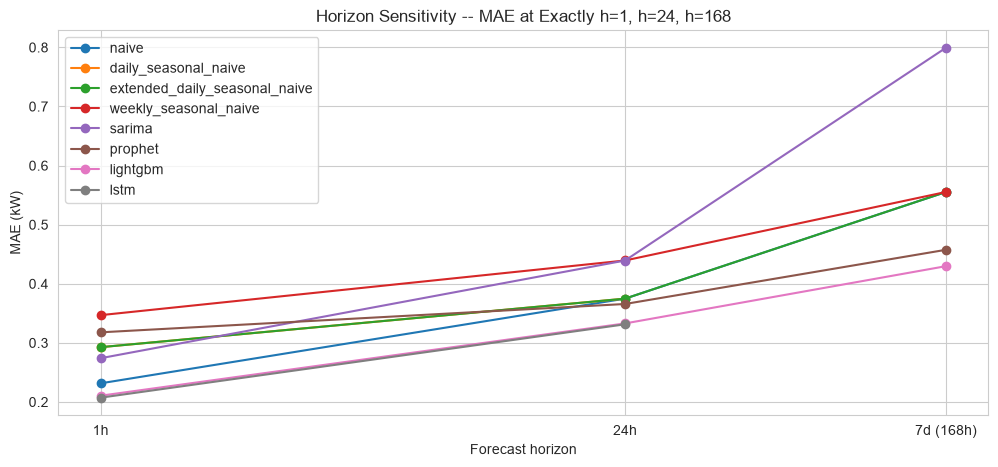

In [13]:
horizons = [1, 24, HORIZON_7D]
fig, ax = plt.subplots()
for method in METHODS_WITH_LSTM:
    values = sensitivity_df.loc[method, ["MAE_1h", "MAE_24h", "MAE_7d"]]
    ax.plot(horizons, values, marker="o", label=method)
ax.set_xscale("log")
ax.set_xticks(horizons)
ax.set_xticklabels(["1h", "24h", "7d (168h)"])
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("MAE (kW)")
ax.set_title("Horizon Sensitivity -- MAE at Exactly h=1, h=24, h=168")
ax.legend()
plt.show()

## Does the 24h winner still win at 1h and 7d?

In [14]:
for label in ["MAE_1h", "MAE_24h", "MAE_7d"]:
    ranked = sensitivity_df[label].dropna().sort_values()
    print(f"{label} ranking: {' < '.join(ranked.index)}")

MAE_1h ranking: lstm < lightgbm < naive < sarima < daily_seasonal_naive < extended_daily_seasonal_naive < prophet < weekly_seasonal_naive
MAE_24h ranking: lstm < lightgbm < prophet < naive < daily_seasonal_naive < extended_daily_seasonal_naive < sarima < weekly_seasonal_naive
MAE_7d ranking: lightgbm < prophet < naive < extended_daily_seasonal_naive < weekly_seasonal_naive < sarima


## Findings

- **LightGBM (and LSTM, where evaluated) are the only approaches that stay
  near the top at every horizon -- the clearest, most confident answer this
  phase can give:** LSTM edges out LightGBM at 1h (0.207 vs. 0.211) and 24h
  (0.331 vs. 0.333, essentially tied), and LightGBM is the outright best at
  7d (0.430, LSTM not evaluated there). Every other method's rank relative
  to these two only gets worse as horizon grows. This directly answers the
  roadmap's second question: yes, the 24h winner is robust -- it keeps
  winning (or nearly so) at both a much shorter and a much longer horizon.

- **SARIMA is the sharpest reversal in the whole investigation: from
  "middling" to "worst" as horizon grows.** It's competitive-ish at 1h
  (0.274, 3rd) and unremarkable at 24h (0.439, tied for worst with weekly
  seasonal naive), but at 7d it's not just worse -- it's the single worst
  method of any kind (0.800), nearly double LightGBM's error and clearly
  worse than trivial persistence (naive: 0.555). Its m=24 (daily-only)
  seasonal structure and fixed autoregressive terms apparently don't
  extrapolate at all gracefully a full week out.

- **Prophet's relative standing improves as horizon grows -- the opposite
  trend from SARIMA:** it's one of the *weaker* methods at 1h (0.318, worse
  than plain persistence, SARIMA, and ARIMA), climbs to a solid 3rd at 24h
  (0.366), and lands clearly in 2nd place at 7d (0.457) -- second only to
  LightGBM.

- **The recency question, closed properly this time: does "daily lag beats
  weekly lag" (Phase 5's 24h finding) survive at 7d, or was it an artifact
  of the short horizon it was measured at?** The original `daily_seasonal_
  naive` can't answer this -- its fixed 24h lag isn't even leak-free past a
  24h horizon (see the bug note below). `extended_daily_seasonal_naive`
  closes that gap: it's mathematically identical to `daily_seasonal_naive`
  whenever horizon<=24 (confirmed here -- their 1h and 24h numbers match to
  6 decimal places, not just approximately) but stays leak-free at any
  horizon by tiling the most recent 24h block forward instead of looking up
  a different day-ago point per step. At 7d, its **aggregate** MAE (0.552,
  averaged across all 168 steps) is still slightly better than `weekly_
  seasonal_naive`'s (0.564) -- recency keeps its edge over exact same-day-
  last-week matching even a full week out, extending Phase 5's finding
  rather than overturning it. (At the single *exact* h=168 step specifically
  the two are numerically tied with `naive` too -- see the structural note
  below for why that's expected, not a new result in its own right.)

- **A neat structural check, confirmed rather than assumed:** whenever a
  lag-based baseline's lag exactly divides the requested horizon, its
  forecast for that final step algebraically reduces to "the value observed
  at the origin." Since 168 = 24 x 7, `naive`, `weekly_seasonal_naive`
  (lag=168), and `extended_daily_seasonal_naive` (24h tile, and 168 is a
  whole number of tiles) all land on exactly the same prediction at h=168 --
  visible in the sensitivity plot as three lines converging to one point.
  Their aggregate curves (h=1...168 averaged) are not identical, though --
  only this one specific step is a mathematical tie, and the aggregate table
  above is where their real difference shows.

- **Why LSTM wasn't extended to 7d:** unlike SARIMA/Prophet/LightGBM,
  extending LSTM to a 168-step horizon isn't a parameter change -- its
  output head (`Linear(hidden_size, horizon)`) is sized at construction
  time, so a 7d model needs a new architecture, a fresh Optuna search
  (plausibly over a longer lookback too, to see prior weekly cycles), and a
  full retraining cycle, all against a dataset small enough that the
  existing 24h LSTM already overfit within 2-3 epochs. Given Part A found
  LightGBM and LSTM statistically indistinguishable at 24h (Diebold-Mariano
  p=0.098) and LightGBM's 7d extension was a cheap reuse of its existing
  direct multi-horizon machinery, the rebuild cost here was disproportionate
  to the marginal information it would add -- LightGBM already answers
  "does the ML/DL tier hold up at 7d" on its own.

- **A real bug was caught and fixed while building this phase:**
  `daily_seasonal_naive`'s fixed 24h lag silently produces future-leaking
  forecasts whenever the requested horizon exceeds 24h -- its lookback for
  the farthest step becomes a timestamp *after* the origin. This only
  surfaced because Part B is the first time any method in this project has
  been asked for a horizon longer than its own lag. `src/evaluation/
  baselines.py`'s `_lagged_forecast` now raises a `ValueError` if
  `horizon > lag_hours`; `extended_daily_seasonal_naive` is the leak-free
  replacement used at 7d instead.

- **What this means for Phase 10:** the practical recommendation is
  horizon-dependent in a way worth stating plainly rather than picking one
  "best" model overall. LightGBM (or LSTM, statistically indistinguishable
  per Part A's DM test) is the safe default across the board. If only a
  single classical/interpretable fallback were needed, Prophet is the
  better choice for longer horizons and SARIMA is the worse one -- the
  opposite of what their similar 24h-aggregate standing might have
  suggested before this phase re-ran them at genuinely different horizons.
